In [24]:
from pathlib import Path
DATA_PATH = Path("../data/raw/PS_20174392719_1491204439457_log.csv")
print(DATA_PATH.exists())
print(DATA_PATH)

True
..\data\raw\PS_20174392719_1491204439457_log.csv


In [25]:
import numpy as np
import pandas as pd
df_sample = pd.read_csv(DATA_PATH, nrows = 100000)
print(df_sample.shape)
print(df_sample.info())

(100000, 11)
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   step            100000 non-null  int64  
 1   type            100000 non-null  str    
 2   amount          100000 non-null  float64
 3   nameOrig        100000 non-null  str    
 4   oldbalanceOrg   100000 non-null  float64
 5   newbalanceOrig  100000 non-null  float64
 6   nameDest        100000 non-null  str    
 7   oldbalanceDest  100000 non-null  float64
 8   newbalanceDest  100000 non-null  float64
 9   isFraud         100000 non-null  int64  
 10  isFlaggedFraud  100000 non-null  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 8.4 MB
None


In [26]:
df_sample.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [27]:
df_sample.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,100000.000000,1.000000e+05,1.000000e+05,1.000000e+05,1.000000e+05,1.000000e+05,100000.000000,100000.0
mean,8.499640,1.736022e+05,8.777575e+05,8.940619e+05,8.805048e+05,1.184041e+06,0.001160,0.0
std,1.825545,3.443003e+05,2.673284e+06,2.711318e+06,2.402267e+06,2.802350e+06,0.034039,0.0
min,1.000000,3.200000e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.0
25%,8.000000,9.963562e+03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.0
50%,9.000000,5.274552e+04,2.006150e+04,0.000000e+00,2.083943e+04,4.990918e+04,0.000000,0.0
75%,10.000000,2.117631e+05,1.901920e+05,2.148132e+05,5.882724e+05,1.058186e+06,0.000000,0.0
max,10.000000,1.000000e+07,3.379739e+07,3.400874e+07,3.400874e+07,3.894623e+07,1.000000,0.0


In [28]:
df_sample["type"].value_counts()

type
PAYMENT     39512
CASH_OUT    30718
CASH_IN     20185
TRANSFER     8597
DEBIT         988
Name: count, dtype: int64

In [29]:
df_sample["isFraud"].value_counts()

isFraud
0    99884
1      116
Name: count, dtype: int64

In [30]:
df_sample["isFraud"].value_counts(normalize=True)*100

isFraud
0    99.884
1     0.116
Name: proportion, dtype: float64

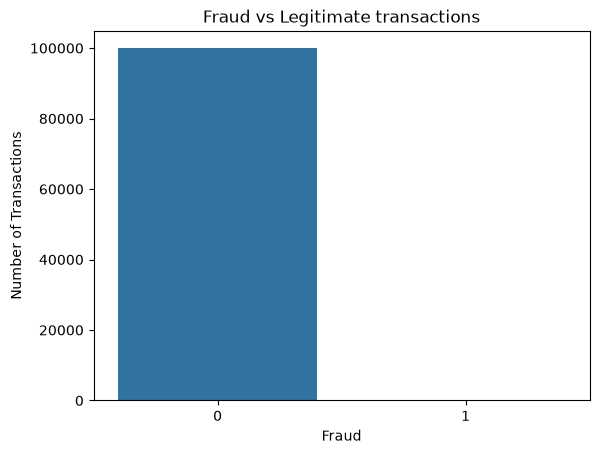

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.countplot(data = df_sample, x = "isFraud")

plt.title("Fraud vs Legitimate transactions")
plt.xlabel("Fraud")
plt.ylabel("Number of Transactions")
plt.show()

In [32]:
fraud_by_type = pd.crosstab(
    df_sample["type"],
    df_sample["isFraud"]
)

fraud_by_type

isFraud,0,1
type,,
CASH_IN,20185,0
CASH_OUT,30659,59
DEBIT,988,0
PAYMENT,39512,0
TRANSFER,8540,57


In [33]:
fraud_rate_by_type = (
    df_sample.groupby("type")["isFraud"]
    .mean()
    .sort_values(ascending = False)*100
)
fraud_rate_by_type

type
TRANSFER    0.663022
CASH_OUT    0.192070
CASH_IN     0.000000
DEBIT       0.000000
PAYMENT     0.000000
Name: isFraud, dtype: float64

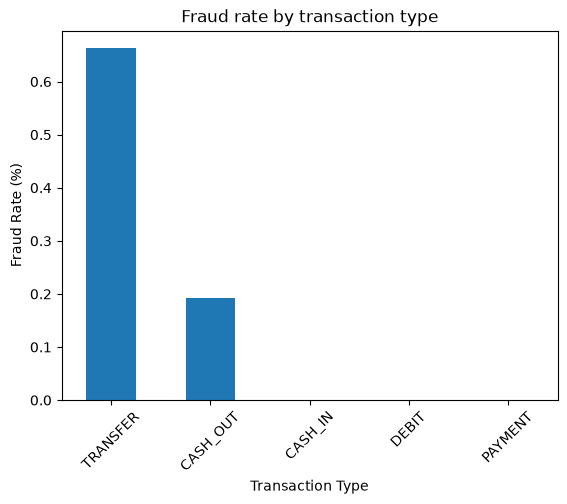

In [34]:
fraud_rate_by_type.plot(kind ="bar")
plt.title("Fraud rate by transaction type")
plt.xlabel("Transaction Type")
plt.ylabel("Fraud Rate (%)")
plt.xticks(rotation = 45)
plt.show()

In [35]:
df_sample.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [36]:
df_sample.duplicated().sum()

np.int64(0)

In [37]:
df_sample.nunique()

step                  10
type                   5
amount             99470
nameOrig          100000
oldbalanceOrg      58013
newbalanceOrig     48118
nameDest           51551
oldbalanceDest     53663
newbalanceDest     19158
isFraud                2
isFlaggedFraud         1
dtype: int64

In [38]:
df_sample.groupby("isFraud")["amount"].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,99884.0,173174.873646,3.403085e+05,0.32,9952.8925,52759.675,211702.185,6419835.27
1,116.0,541578.424138,1.535067e+06,164.00,17246.0000,39077.815,296154.595,10000000.00


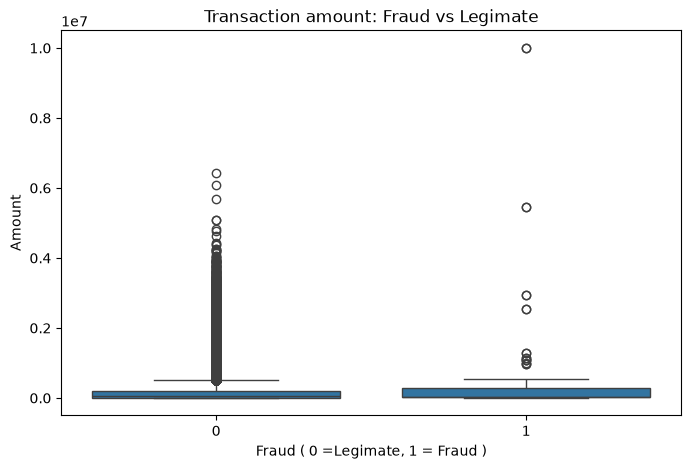

In [39]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data = df_sample,
    x="isFraud",
    y ="amount"  
)      
plt.title("Transaction amount: Fraud vs Legimate")
plt.xlabel("Fraud ( 0 =Legimate, 1 = Fraud )")
plt.ylabel("Amount")
plt.show()

In [40]:
df_sample["log_amount"] = np.log1p(df_sample["amount"])

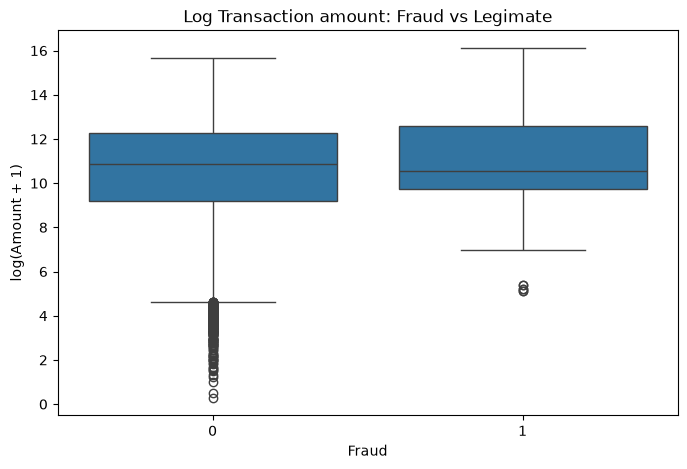

In [41]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data = df_sample,
    x="isFraud",
    y="log_amount"
)
plt.title("Log Transaction amount: Fraud vs Legimate")
plt.xlabel("Fraud")
plt.ylabel("log(Amount + 1)")
plt.show()

In [42]:
df_sample["origin_balance_change"] = (
    df_sample["oldbalanceOrg"] -
    df_sample["newbalanceOrig"]
)

df_sample["destination_balance_change"] = (
    df_sample["newbalanceDest"] -
    df_sample["oldbalanceDest"]
)

In [43]:
df_sample.groupby("isFraud")[
    [
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "origin_balance_change",
    "destination_balance_change"
    ]
].mean()

,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,origin_balance_change,destination_balance_change
isFraud,,,,,,
0,878135.006244,895066.460620,881263.347771,1.184652e+06,-16931.454376,303388.747857
1,552710.135086,29080.483707,227348.217328,6.582112e+05,523629.651379,430863.010603


In [44]:
df_sample["origin_error"] = ( 
    df_sample["oldbalanceOrg"] - df_sample["amount"] - df_sample["newbalanceOrig"]
)

In [45]:
df_sample.groupby("isFraud")["origin_error"].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,99884.0,-190106.328022,352973.333229,-6388051.27,-248123.185,-38960.75,-7.275958e-12,1.000000e-02
1,116.0,-17948.772759,111299.258927,-1078013.76,0.000,0.00,0.000000e+00,1.746230e-10


In [46]:
df_sample.groupby(["type", "isFraud"])["amount"].agg(["mean","std","min","max","count"])

mean           std     min          max  count
type     isFraud                                                         
CASH_IN  0        173967.481693  1.352808e+05   57.98   1289407.91  20185
CASH_OUT 0        193418.449503  1.464359e+05   11.83   1255048.95  30659
         1        523382.823729  1.528012e+06  164.00  10000000.00     59
DEBIT    0          4096.025395  7.391140e+03    3.83    130835.31    988
PAYMENT  0         10912.861894  9.241633e+03    0.32     83428.95  39512
TRANSFER 0        868924.279351  7.894776e+05  182.02   6419835.27   8540
         1        560412.466667  1.555692e+06  164.00  10000000.00     57

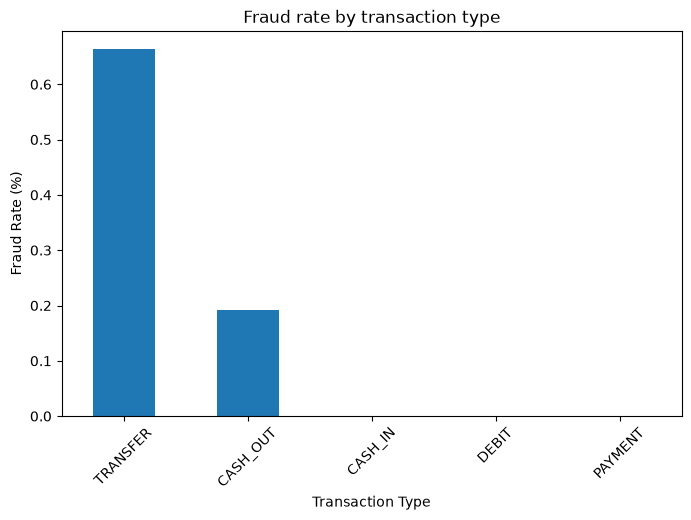

In [47]:
fraud_rate = (
    df_sample.groupby("type")["isFraud"]
    .mean()
    .mul(100)
    .sort_values(ascending = False)
)
plt.figure(figsize = (8,5))
fraud_rate.plot(kind = "bar")
plt.title("Fraud rate by transaction type")
plt.xlabel("Transaction Type")
plt.ylabel("Fraud Rate (%)")
plt.xticks(rotation = 45)
plt.show()

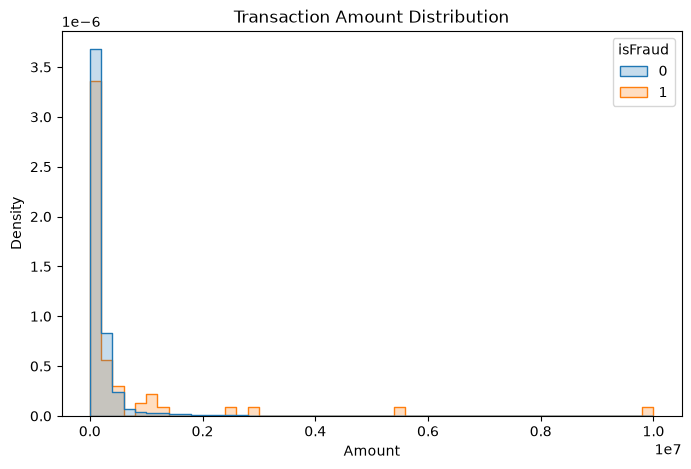

In [49]:
plt.figure(figsize = (8,5))
sns.histplot(
    data = df_sample,
    x ="amount",
    hue="isFraud",
    bins = 50,
    element ="step",
    stat="density",
    common_norm= False
)

plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Density")

plt.show()